# Transformers through the Vision Transformer

In the previous lesson, a convolutional neural network classified CIFAR-10 by learning local filters and gradually reducing the image resolution. Here we will reach transformers from the same computer-vision starting point.

By the end of this notebook, you will be able to:

- compare max pooling with splitting an image into patches,
- convert a tensor from `(batch, channels, height, width)` to a sequence,
- implement scaled dot-product attention,
- explain why a ViT needs positional information, and
- train a small Vision Transformer on CIFAR-10.

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

print(f"PyTorch: {torch.__version__}")
print(f"Using:   {device}")

PyTorch: 2.13.0+cu130
Using:   cuda


# CIFAR-10 again

CIFAR-10 images have shape `3 x 32 x 32`. We use the same normalization as the computer-vision lesson. Random crops and horizontal flips give the training set some extra variety; the test set is never augmented.

In [2]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
BATCH_SIZE = 128

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

DATA_ROOT = "../4. Computer Vision/data"
cifar_train = datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=True, transform=train_transform
)
cifar_test = datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=True, transform=test_transform
)
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": device.type == device,
}
train_loader = DataLoader(cifar_train, shuffle=True, **loader_options)
test_loader = DataLoader(cifar_test, shuffle=False, **loader_options)
class_names = cifar_train.classes

images, labels = next(iter(train_loader))
print(f"Training images: {len(cifar_train):,}")
print(f"Test images:     {len(cifar_test):,}")
print(f"Image batch:     {tuple(images.shape)}")
print(f"Label batch:     {tuple(labels.shape)}")

Training images: 50,000
Test images:     10,000
Image batch:     (128, 3, 32, 32)
Label batch:     (128,)


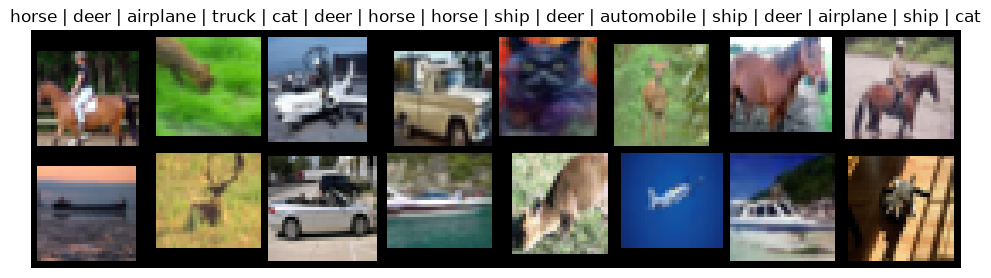

In [45]:
def denormalize(batch):
    mean = torch.tensor(CIFAR_MEAN).reshape(1, 3, 1, 1)
    std = torch.tensor(CIFAR_STD).reshape(1, 3, 1, 1)
    return (batch.cpu() * std + mean).clip(0, 1)

grid = make_grid(denormalize(images[:16]), nrow=8, padding=2)
plt.figure(figsize=(12, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title(" | ".join(class_names[int(label)] for label in labels[:16]))
plt.axis("off")
plt.show()

# From max pooling to patches

Recall that `MaxPool2d(2)` replaces every non-overlapping 2 x 2 region with its largest value. It halves both spatial dimensions, so it reduces the number of spatial locations by four.

Pooling deliberately throws information away. A standard ViT does **not** use max pooling. Instead, it divides the image into non-overlapping patches and keeps all the values in each patch as one vector. Both operations reduce the spatial grid, but patching preserves enough information for a learned projection.

In [46]:
pool_input = torch.tensor([
    [1.0, 3.0, 2.0, 0.0],
    [4.0, 2.0, 1.0, 5.0],
    [0.0, 1.0, 3.0, 2.0],
    [2.0, 6.0, 1.0, 4.0],
]).reshape(1, 1, 4, 4)
pool_output = nn.MaxPool2d(2)(pool_input)

print("Before pooling:")
print(pool_input[0, 0])
print("\nAfter 2 x 2 max pooling:")
print(pool_output[0, 0])
print(f"\nShape: {tuple(pool_input.shape)} -> {tuple(pool_output.shape)}")

Before pooling:
tensor([[1., 3., 2., 0.],
        [4., 2., 1., 5.],
        [0., 1., 3., 2.],
        [2., 6., 1., 4.]])

After 2 x 2 max pooling:
tensor([[4., 5.],
        [6., 4.]])

Shape: (1, 1, 4, 4) -> (1, 1, 2, 2)


## Patching by hand

For CIFAR-10, 4 x 4 patches are a useful scale:

- each side contains `32 / 4 = 8` patches,
- the image contains `8 x 8 = 64` patches, and
- each RGB patch contains `3 x 4 x 4 = 48` values.

`unfold` exposes the patch grid without losing the values. The `permute` then places the patch rows and columns before the channels, and `reshape` turns the two-dimensional grid into a sequence.

In [47]:
PATCH_SIZE = 4
patch_grid = images.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
patches = patch_grid.permute(0, 2, 3, 1, 4, 5).reshape(
    images.shape[0], -1, 3 * PATCH_SIZE * PATCH_SIZE
)

print(f"Images:     {tuple(images.shape)}  (B, C, H, W)")
print(f"Patch grid: {tuple(patch_grid.shape)}")
print(f"Sequence:   {tuple(patches.shape)}  (B, N, patch values)")
assert patches.shape == (images.shape[0], 64, 48)

Images:     (128, 3, 32, 32)  (B, C, H, W)
Patch grid: (128, 3, 8, 8, 4, 4)
Sequence:   (128, 64, 48)  (B, N, patch values)


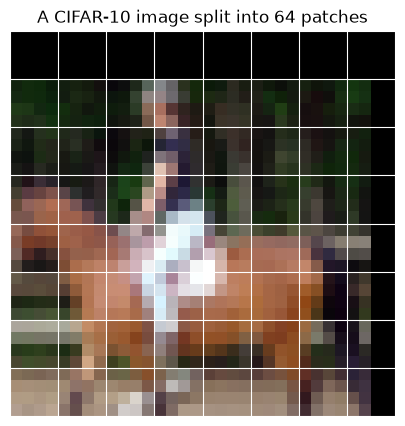

In [48]:
example = denormalize(images[:1])[0].permute(1, 2, 0)
plt.figure(figsize=(5, 5))
plt.imshow(example)
for boundary in range(0, 33, PATCH_SIZE):
    plt.axhline(boundary - 0.5, color="white", linewidth=0.8)
    plt.axvline(boundary - 0.5, color="white", linewidth=0.8)
plt.title("A CIFAR-10 image split into 64 patches")
plt.axis("off")
plt.show()

## A convolution can create patch embeddings

The 48 raw numbers in a patch are not yet a useful token. We learn a linear projection from 48 values to an embedding dimension `C`. Applying the same projection to every patch is exactly what a convolution does when its kernel size and stride both equal the patch size.

The convolution returns `(B, C, H, W)`. Attention expects a sequence `(B, N, C)`, so these two operations are essential:

```python
x = x.flatten(2)       # (B, C, H * W)
x = x.transpose(1, 2) # (B, H * W, C)
```

In [49]:
EMBED_DIM = 96
patch_projection = nn.Conv2d(
    in_channels=3, out_channels=EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE
)
feature_map = patch_projection(images[:4])
tokens = feature_map.flatten(2).transpose(1, 2)

print(f"After patch projection: {tuple(feature_map.shape)}  (B, C, H, W)")
print(f"After flatten:          {tuple(feature_map.flatten(2).shape)}  (B, C, H * W)")
print(f"After transpose:        {tuple(tokens.shape)}  (B, H * W, C)")
assert tokens.shape == (4, 64, EMBED_DIM)

After patch projection: (4, 96, 8, 8)  (B, C, H, W)
After flatten:          (4, 96, 64)  (B, C, H * W)
After transpose:        (4, 64, 96)  (B, H * W, C)


# Positional embeddings

Self-attention compares token contents, but by itself it has no concept of top, bottom, left, or right. If we rearranged all patch tokens, attention would rearrange its outputs in exactly the same way. That is a problem for images: a blue patch above a brown patch may mean sky over ground, while the reverse arrangement means something different.

A ViT therefore adds one position vector to each token. The original ViT learned these vectors along with the rest of the model. We will also prepend a learned `[CLS]` token. After the transformer blocks, that token summarizes the image and is sent to the classifier.

Addition is possible because token embeddings and positional embeddings have the same final dimension. The position changes the representation but not its shape.

In [50]:
class_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
position_embedding = nn.Parameter(torch.randn(1, 65, EMBED_DIM) * 0.02)

class_tokens = class_token.expand(tokens.shape[0], -1, -1)
tokens_with_class = torch.cat((class_tokens, tokens), dim=1)
positioned_tokens = tokens_with_class + position_embedding

print(f"Patch tokens:          {tuple(tokens.shape)}")
print(f"With [CLS] token:      {tuple(tokens_with_class.shape)}")
print(f"Positional embeddings: {tuple(position_embedding.shape)}")
print(f"Result:                {tuple(positioned_tokens.shape)}")

Patch tokens:          (4, 64, 96)
With [CLS] token:      (4, 65, 96)
Positional embeddings: (1, 65, 96)
Result:                (4, 65, 96)


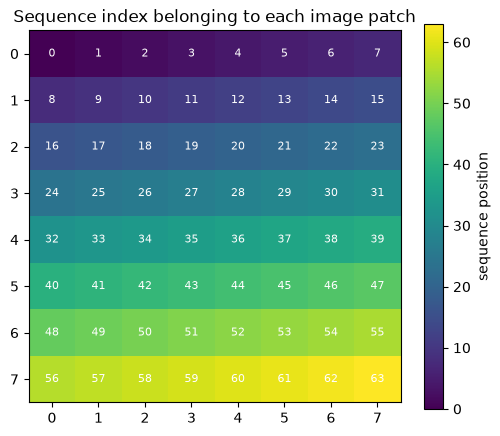

In [51]:
position_numbers = torch.arange(64).reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(position_numbers, cmap="viridis")
for row in range(8):
    for column in range(8):
        plt.text(column, row, str(int(position_numbers[row, column])), ha="center", va="center", color="white", fontsize=8)
plt.title("Sequence index belonging to each image patch")
plt.colorbar(label="sequence position")
plt.show()

# Self-attention

Every token is projected into three vectors:

- a **query** asks what information this token needs,
- a **key** describes what each token offers, and
- a **value** contains the information that can be collected.

For query, key, and value tensors shaped `(B, N, C)`, scaled dot-product attention is

$$\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{C}}\right)V$$

`Q @ K.transpose(-2, -1)` compares every patch with every other patch and produces `(B, N, N)` scores. Softmax turns each row into weights that sum to one. Dividing by `sqrt(C)` prevents large vectors from making softmax excessively confident.

## Exercise: implement attention

Complete the computation after the image has already been reshaped and transposed from `(B, C, H, W)` to `(B, H * W, C)`. Your function should return both the mixed values and the attention weights.

Try it before revealing or running the solution below. Check that the output has the same shape as `V` and every row of attention weights sums to one.

In [52]:
# Student version
# def scaled_dot_product_attention(q, k, v):
#     d_k = q.shape[-1]
#     scores = ...
#     weights = ...
#     output = ...
#     return output, weights

### Solution

In [53]:
def scaled_dot_product_attention(q, k, v):
    d_k = q.shape[-1]
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)
    weights = scores.softmax(dim=-1)
    output = weights @ v
    return output, weights

to_q = nn.Linear(EMBED_DIM, EMBED_DIM)
to_k = nn.Linear(EMBED_DIM, EMBED_DIM)
to_v = nn.Linear(EMBED_DIM, EMBED_DIM)
q, k, v = to_q(tokens), to_k(tokens), to_v(tokens)
attention_output, attention_weights = scaled_dot_product_attention(q, k, v)

print(f"Q, K, V:         {tuple(q.shape)}")
print(f"Attention matrix: {tuple(attention_weights.shape)}")
print(f"Output:           {tuple(attention_output.shape)}")
print(f"First row sums to: {attention_weights[0, 0].sum().item():.4f}")
assert attention_output.shape == v.shape
assert torch.allclose(attention_weights.sum(dim=-1), torch.ones_like(attention_weights[..., 0]))

Q, K, V:         (4, 64, 96)
Attention matrix: (4, 64, 64)
Output:           (4, 64, 96)
First row sums to: 1.0000


## Multi-head attention

One attention calculation can learn one style of relationship. Multi-head attention splits the embedding into smaller groups and performs the same calculation in parallel. With an embedding dimension of 96 and four heads, each head works with 24 features. One head might connect similar colors while another learns relationships between object parts.

The implementation below contains the same three lines as the exercise. The extra `reshape` and `permute` operations only separate and later recombine the heads.

In [54]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.output = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.shape
        qkv = self.qkv(x).reshape(
            batch_size, num_tokens, 3, self.num_heads, self.head_dim
        )
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)
        weights = self.dropout(scores.softmax(dim=-1))
        attended = weights @ v

        attended = attended.transpose(1, 2).reshape(batch_size, num_tokens, embed_dim)
        return self.output(attended)

# A transformer block

Attention lets tokens exchange information. A small feed-forward network then transforms each token separately. Residual connections preserve the previous representation, while layer normalization keeps activation scales manageable.

Unlike batch normalization, `LayerNorm` normalizes each token's features and does not depend on other examples in the batch.

In [55]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# A small ViT for CIFAR-10

ViT-B/16, a commonly cited original configuration, uses 12 blocks, a 768-dimensional embedding, and about 86 million parameters. That is inappropriate for 32 x 32 images and this course.

Our model uses 4 x 4 patches, three blocks, a 96-dimensional embedding, four heads, and an MLP width of 192. It still contains every important ViT component, but has well under one million parameters.

In [56]:
class TinyViT(nn.Module):
    def __init__(
        self, image_size=32, patch_size=4, num_classes=10, embed_dim=96,
        depth=3, num_heads=4, mlp_dim=192, dropout=0.1,
    ):
        super().__init__()
        assert image_size % patch_size == 0
        num_patches = (image_size // patch_size) ** 2

        self.patch_embedding = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim) * 0.02
        )
        self.embedding_dropout = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, images):
        x = self.patch_embedding(images)
        x = x.flatten(2).transpose(1, 2)
        class_tokens = self.class_token.expand(x.shape[0], -1, -1)
        x = torch.cat((class_tokens, x), dim=1)
        x = self.embedding_dropout(x + self.position_embedding)
        x = self.blocks(x)
        return self.classifier(self.norm(x[:, 0]))

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

torch.manual_seed(SEED)
model = TinyViT()
parameter_count = count_parameters(model)
print(model)
print(f"\nTrainable parameters: {parameter_count:,}")
print(f"Compared with ViT-B/16: about {86_000_000 / parameter_count:.0f}x smaller")

TinyViT(
  (patch_embedding): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): MultiHeadSelfAttention(
        (qkv): Linear(in_features=96, out_features=288, bias=True)
        (output): Linear(in_features=96, out_features=96, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=96, out_features=192, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=192, out_features=96, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): Multi

## Trace the shapes

Shape checks catch many transformer bugs. Notice that the 64 patch tokens become 65 tokens after `[CLS]` is prepended. Every block preserves `(B, N, C)`.

In [57]:
with torch.inference_mode():
    x = model.patch_embedding(images[:4])
    print(f"Patch feature map: {tuple(x.shape)}")
    x = x.flatten(2).transpose(1, 2)
    print(f"Patch sequence:    {tuple(x.shape)}")
    x = torch.cat((model.class_token.expand(4, -1, -1), x), dim=1)
    x = x + model.position_embedding
    print(f"With positions:    {tuple(x.shape)}")
    for index, block in enumerate(model.blocks, start=1):
        x = block(x)
        print(f"After block {index}:    {tuple(x.shape)}")
    logits = model.classifier(model.norm(x[:, 0]))
    print(f"Class logits:      {tuple(logits.shape)}")

assert logits.shape == (4, 10)

Patch feature map: (4, 96, 8, 8)
Patch sequence:    (4, 64, 96)
With positions:    (4, 65, 96)
After block 1:    (4, 65, 96)
After block 2:    (4, 65, 96)
After block 3:    (4, 65, 96)
Class logits:      (4, 10)


# Train the ViT

We use AdamW, which combines Adam with weight decay, and gradually lower the learning rate with cosine annealing. Twelve epochs are enough to verify that this compact model learns, not to reach state-of-the-art accuracy.

Transformers generally have fewer built-in assumptions about images than CNNs and benefit strongly from more data, augmentation, and longer training. That is part of the comparison, not a defect in the exercise.

In [58]:
loss_function = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_images, batch_labels in tqdm(loader, leave=False):
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(batch_images)
        loss = loss_function(logits, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_labels.size(0)
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_images, batch_labels in loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)
        logits = model(batch_images)
        total_loss += loss_function(logits, batch_labels).item() * batch_labels.size(0)
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

def fit(model, train_loader, test_loader, epochs=12):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_accuracy = evaluate(model, test_loader)
        scheduler.step()
        history.append((train_loss, train_accuracy, test_loss, test_accuracy))
        print(
            f"epoch {epoch:2d}/{epochs} | "
            f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
            f"test loss {test_loss:.3f}, accuracy {test_accuracy:.1%}"
        )

    return history

In [59]:
history = fit(model, train_loader, test_loader, epochs=12)

  0%|          | 0/391 [00:00<?, ?it/s]

epoch  1/12 | train loss 1.816, accuracy 32.1% | test loss 1.666, accuracy 39.3%


  0%|          | 0/391 [00:00<?, ?it/s]

epoch  2/12 | train loss 1.549, accuracy 43.4% | test loss 1.396, accuracy 49.6%


  0%|          | 0/391 [00:00<?, ?it/s]

...

epoch 10/12 | train loss 1.114, accuracy 60.0% | test loss 1.075, accuracy 61.5%


  0%|          | 0/391 [00:00<?, ?it/s]

epoch 11/12 | train loss 1.105, accuracy 60.1% | test loss 1.052, accuracy 62.4%


  0%|          | 0/391 [00:00<?, ?it/s]

epoch 12/12 | train loss 1.097, accuracy 60.3% | test loss 1.061, accuracy 62.1%


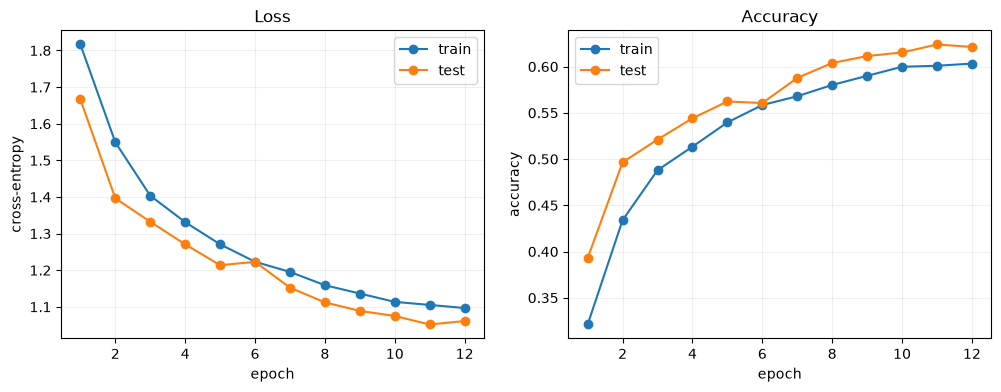

In [60]:
epochs = range(1, len(history) + 1)
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [row[0] for row in history], marker="o", label="train")
axes[0].plot(epochs, [row[2] for row in history], marker="o", label="test")
axes[0].set(title="Loss", xlabel="epoch", ylabel="cross-entropy")
axes[1].plot(epochs, [row[1] for row in history], marker="o", label="train")
axes[1].plot(epochs, [row[3] for row in history], marker="o", label="test")
axes[1].set(title="Accuracy", xlabel="epoch", ylabel="accuracy")
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

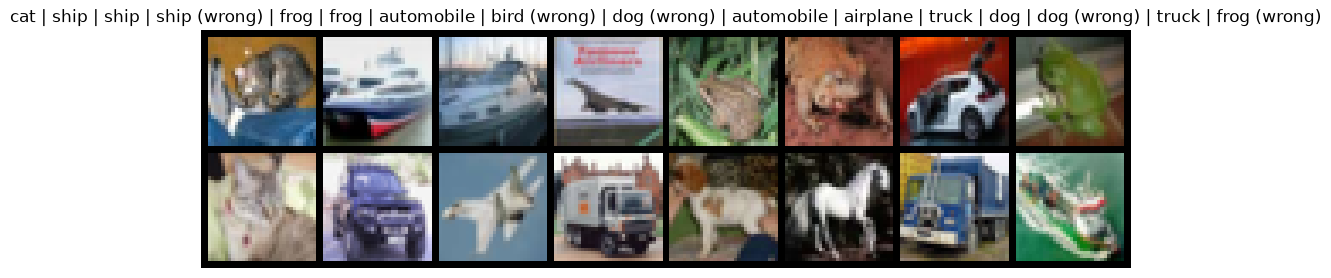

In [61]:
@torch.inference_mode()
def show_predictions(model, loader):
    model.eval()
    batch_images, batch_labels = next(iter(loader))
    predictions = model(batch_images.to(device)).argmax(dim=1).cpu()
    titles = [
        f"{class_names[int(prediction)]}{'' if prediction == label else ' (wrong)'}"
        for prediction, label in zip(predictions[:16], batch_labels[:16])
    ]
    grid = make_grid(denormalize(batch_images[:16]), nrow=8, padding=2)
    plt.figure(figsize=(12, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(" | ".join(titles))
    plt.axis("off")
    plt.show()

show_predictions(model, test_loader)

# What to remember

1. Max pooling reduces a CNN feature map by keeping one maximum per region. A ViT instead turns non-overlapping image patches into tokens.
2. The patch projection initially returns `(B, C, H, W)`. `flatten(2).transpose(1, 2)` changes it to the sequence `(B, H * W, C)`.
3. Attention computes all query-key similarities, scales them, applies softmax, and uses the resulting weights to mix values.
4. Positional embeddings tell attention where patches came from. Without them, patch order has no spatial meaning.
5. Multi-head attention runs several smaller attention calculations in parallel.
6. A practical CIFAR-10 ViT should be far smaller than ViT-B/16.

Questions to consider:

1. What happens to sequence length and attention cost if patch size changes from 4 to 2?
2. Why does the patch projection use `stride=patch_size`?
3. What information would be lost if positional embeddings were removed?
4. How does the role of a `[CLS]` token compare with global average pooling in the CNN?
5. Can you improve test accuracy by changing augmentation, model depth, or training duration without exceeding one million parameters?

# Transfer learning: fine-tune a full-size ViT

Our tiny ViT learned every feature from only 50,000 small images. Production image models usually start from a model that has already learned general visual features from a much larger dataset. We can then **fine-tune** those features for CIFAR-10.

We will use torchvision's ViT-B/16 with SWAG-pretrained weights. This is a full-size, roughly 86-million-parameter Vision Transformer. It expects 224 x 224 images and was pretrained on far more data than CIFAR-10. We replace its 1,000-class ImageNet head with a new 10-class head, then update the whole model.

A test accuracy around 96-98% is a reasonable target for this experiment, but 97% is not guaranteed: results depend on the weight version, random seed, augmentation, and number of epochs. This section also makes an important distinction:

- the small model showed how a ViT works and can be trained from scratch,
- the large model shows why pretrained foundation models are so useful.

In [62]:
from torchvision.models import ViT_B_16_Weights, vit_b_16
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
PRETRAINED_BATCH_SIZE = 64

pretrained_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
pretrained_test_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

pretrained_train = datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=False, transform=pretrained_train_transform
)
pretrained_test = datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=False, transform=pretrained_test_transform
)
pretrained_train_loader = DataLoader(
    pretrained_train, batch_size=PRETRAINED_BATCH_SIZE, shuffle=True, num_workers=0
)
pretrained_test_loader = DataLoader(
    pretrained_test, batch_size=PRETRAINED_BATCH_SIZE, shuffle=False, num_workers=0
)

resized_images, _ = next(iter(pretrained_train_loader))
print(f"Original TinyViT input: (B, 3, 32, 32)")
print(f"Pretrained ViT input:   {tuple(resized_images.shape)}")

Original TinyViT input: (B, 3, 32, 32)
Pretrained ViT input:   (64, 3, 224, 224)


The pretrained model download is about 330 MB and happens only the first time this cell runs. The model's final layer is called `heads.head`. Replacing it discards the old ImageNet class predictions while retaining the useful patch projection and transformer features.

The new head starts randomly initialized. It therefore receives a larger learning rate than the pretrained backbone, which only needs small adjustments.

In [75]:
pretrained_weights = ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1
pretrained_vit = vit_b_16(weights=pretrained_weights)
input_features = pretrained_vit.heads.head.in_features
pretrained_vit.heads.head = nn.Linear(input_features, 10)
pretrained_vit.to(device)

print(f"New classifier:       {pretrained_vit.heads.head}")
print(f"Trainable parameters: {count_parameters(pretrained_vit):,}")
print(f"Running on:           {device}")

New classifier:       Linear(in_features=768, out_features=10, bias=True)
Trainable parameters: 85,806,346
Running on:           cuda


In [76]:
pretrained_loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)

def fine_tune_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_images, batch_labels in tqdm(loader, leave=False):
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch_images)
        loss = pretrained_loss_function(logits, batch_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch_labels.size(0)
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

@torch.inference_mode()
def evaluate_pretrained(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_images, batch_labels in loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        logits = model(batch_images)
        loss = pretrained_loss_function(logits, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

def fine_tune(model, train_loader, test_loader):
    head_parameters = list(model.heads.parameters())
    head_parameter_ids = {id(parameter) for parameter in head_parameters}
    backbone_parameters = [
        parameter for parameter in model.parameters()
        if id(parameter) not in head_parameter_ids
    ]

    optimizer = torch.optim.Adam([
        {"params": backbone_parameters, "lr": 2e-5},
        {"params": head_parameters, "lr": 3e-4},
    ])

    train_loss, train_accuracy = fine_tune_one_epoch(
        model, train_loader, optimizer
    )
    test_loss, test_accuracy = evaluate_pretrained(model, test_loader)

    print(
        f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
        f"test loss {test_loss:.3f}, accuracy {test_accuracy:.1%}"
    )

    return [(train_loss, train_accuracy, test_loss, test_accuracy)]

In [77]:
fine_tuning_history = fine_tune(
    pretrained_vit, pretrained_train_loader, pretrained_test_loader
)

  0%|          | 0/782 [00:00<?, ?it/s]

train loss 0.797, accuracy 87.4% | test loss 0.621, accuracy 95.1%


The large accuracy jump does not come only from increasing the parameter count. The decisive advantage is **pretraining**: ViT-B/16 begins with useful visual representations instead of discovering edges, textures, shapes, and object parts from CIFAR-10 alone.

For an even stronger experiment, train for 10-20 epochs and save the checkpoint with the highest test accuracy rather than only using the final epoch. In a real project, a validation set would select the checkpoint and the test set would be evaluated once at the end.